In [27]:
# Import Packages
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [28]:
# Universal Variables
distance = ctrl.Antecedent(np.arange(0, 101, 1), 'distance')
rel_speed = ctrl.Antecedent(np.arange(-50, 51, 1), 'rel_speed')
slope = ctrl.Antecedent(np.arange(-10, 11, 1), 'slope')
acceleration = ctrl.Consequent(np.arange(-5, 6, 1), 'acceleration')

In [29]:
# Membership Function
distance['close'] = fuzz.trapmf(distance.universe, [0, 0, 10, 30])
distance['medium'] = fuzz.trimf(distance.universe, [20, 50, 80])
distance['far'] = fuzz.trapmf(distance.universe, [60, 80, 100, 100])

rel_speed['slower'] = fuzz.trapmf(rel_speed.universe, [-50, -50, -20, -5])
rel_speed['same'] = fuzz.trimf(rel_speed.universe, [-10, 0, 10])
rel_speed['faster'] = fuzz.trapmf(rel_speed.universe, [5, 20, 50, 50])

slope['downhill'] = fuzz.trapmf(slope.universe, [-10, -10, -5, -1])
slope['flat'] = fuzz.trimf(slope.universe, [-2, 0, 2])
slope['uphill'] = fuzz.trapmf(slope.universe, [1, 5, 10, 10])

acceleration['brake'] = fuzz.trapmf(acceleration.universe, [-5, -5, -3, -1])
acceleration['maintain'] = fuzz.trimf(acceleration.universe, [-2, 0, 2])
acceleration['accelerate'] = fuzz.trapmf(acceleration.universe, [1, 3, 5, 5])

In [30]:
# Rule Definitons
rule1 = ctrl.Rule(distance['close'] & rel_speed['faster'], acceleration['brake'])
rule2 = ctrl.Rule(distance['close'] & rel_speed['same'], acceleration['brake'])
rule3 = ctrl.Rule(distance['medium'] & rel_speed['faster'], acceleration['brake'])
rule4 = ctrl.Rule(distance['medium'] & rel_speed['same'], acceleration['maintain'])
rule5 = ctrl.Rule(distance['medium'] & rel_speed['slower'], acceleration['accelerate'])
rule6 = ctrl.Rule(distance['far'] & rel_speed['same'], acceleration['accelerate'])
rule7 = ctrl.Rule(distance['far'] & rel_speed['slower'], acceleration['accelerate'])
rule8 = ctrl.Rule(slope['uphill'] & rel_speed['same'], acceleration['accelerate'])
rule9 = ctrl.Rule(slope['downhill'] & rel_speed['same'], acceleration['brake'])

In [31]:
# Control System
acc_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9])
acc_sim = ctrl.ControlSystemSimulation(acc_ctrl)

In [32]:
# Simuation
acc_sim.input['distance'] = 40      # meter
acc_sim.input['rel_speed'] = 10     # km/h lebih cepat
acc_sim.input['slope'] = 2          # sedikit menanjak

In [35]:
# Categorize outpu
acc_sim.compute()
output_val = acc_sim.output['acceleration']

if output_val < -1:
    result = "Brake"
elif -1 <= output_val <= 1:
    result = "Maintain"
else:
    result = "Accelerate"

print(f"Hasil Output (Acceleration Command): {output_val:.2f} m/s² ({result})")

Hasil Output (Acceleration Command): -3.16 m/s² (Brake)


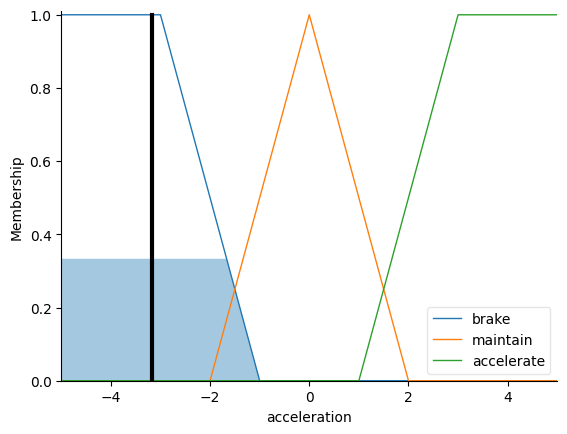

In [36]:
# Visualization
acceleration.view(sim=acc_sim)